**Project 1: Predictive Maintenance for Industrial Equipment**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv('machine_failure.csv')
df.head(15)

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0
5,110,3,3,4,6,1,21,4,1,0
6,100,7,5,6,4,1,77,4,1,0
7,31,1,5,4,5,4,21,4,1,0
8,180,7,4,6,3,3,31,4,1,0
9,2800,0,3,3,7,0,39,3,1,0


In [3]:
df.shape

(944, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   footfall     944 non-null    int64
 1   tempMode     944 non-null    int64
 2   AQ           944 non-null    int64
 3   USS          944 non-null    int64
 4   CS           944 non-null    int64
 5   VOC          944 non-null    int64
 6   RP           944 non-null    int64
 7   IP           944 non-null    int64
 8   Temperature  944 non-null    int64
 9   fail         944 non-null    int64
dtypes: int64(10)
memory usage: 73.9 KB


In [5]:
df.describe()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
count,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000
mean,306.381356,3.727754,4.325212,2.939619,5.394068,2.842161,47.043432,4.565678,16.331568,0.416314
std,1082.606745,2.677235,1.438436,1.383725,1.269349,2.273337,16.423130,1.599287,5.974781,0.493208
min,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,19.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,3.000000,2.000000,5.000000,1.000000,34.000000,3.000000,14.000000,0.000000
50%,22.000000,3.000000,4.000000,3.000000,6.000000,2.000000,44.000000,4.000000,17.000000,0.000000
75%,110.000000,7.000000,6.000000,4.000000,6.000000,5.000000,58.000000,6.000000,21.000000,1.000000
max,7300.000000,7.000000,7.000000,7.000000,7.000000,6.000000,91.000000,7.000000,24.000000,1.000000


In [6]:
df.isnull().sum()

footfall       0
tempMode       0
AQ             0
USS            0
CS             0
VOC            0
RP             0
IP             0
Temperature    0
fail           0
dtype: int64

In [7]:
df['fail'].value_counts()

fail
0    551
1    393
Name: count, dtype: int64

c:\Users\srinu\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


<Axes: xlabel='fail', ylabel='count'>

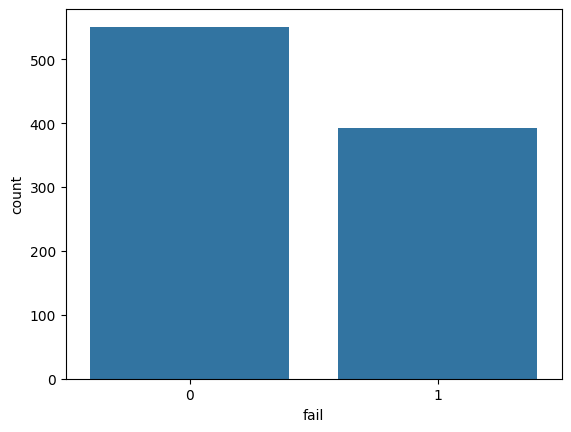

In [8]:
sns.countplot(data=df,x='fail')

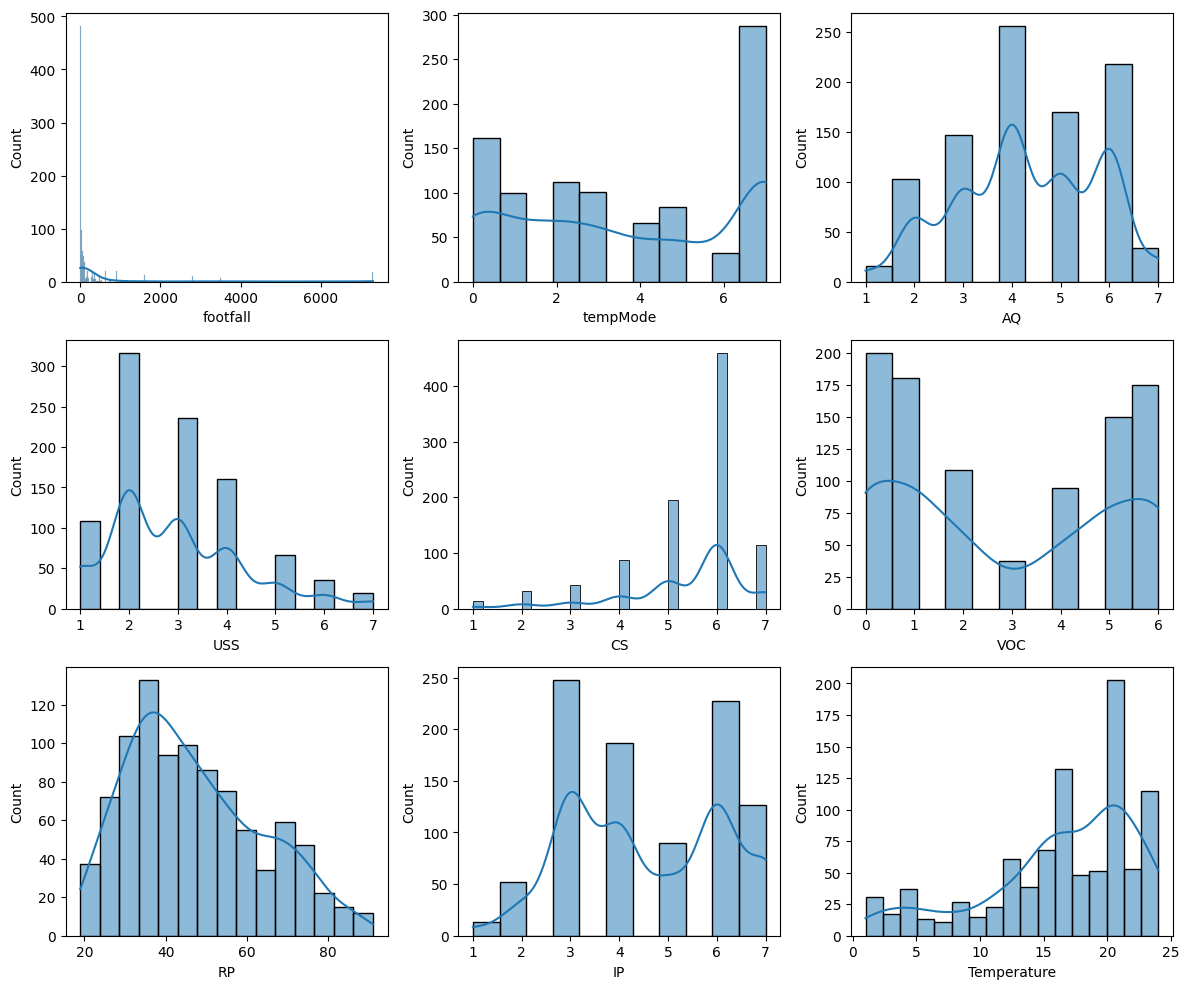

In [9]:
l = [k for k in df.drop('fail', axis=1).columns]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, col in enumerate(l):
    sns.histplot(df[col], ax=axes[i//3, i%3], kde=True)

plt.tight_layout()
plt.show()

c:\Users\srinu\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


<Axes: ylabel='footfall'>

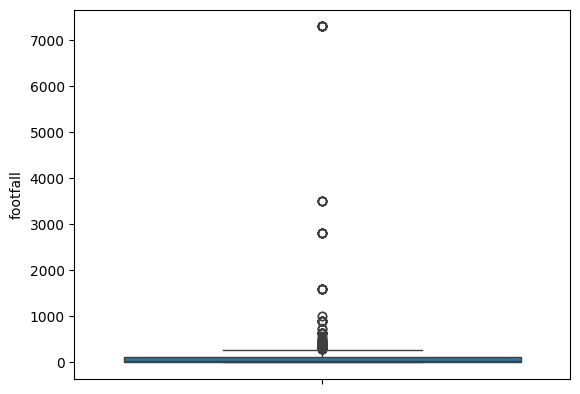

In [10]:
sns.boxplot(data=df,y='footfall')

In [11]:
Q1 = df['footfall'].quantile(0.25)
Q3 = df['footfall'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['footfall'] >= lower) & (df['footfall'] <= upper)]

In [12]:
df.shape

(790, 10)

In [13]:
x=df.drop('fail',axis=1)
y=df['fail']

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=15,test_size=0.2,stratify=y)

In [15]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=15)

x_train, y_train = sm.fit_resample(x_train, y_train)

In [16]:
print(df.shape)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(790, 10)
(710, 9)
(158, 9)
(710,)
(158,)


In [17]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test = sc.transform(x_test)

**Logistic Regression**

In [18]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [19]:
y_pred=model.predict(x_test)
y_pred

array([0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0], dtype=int64)

In [20]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_auc_score
cm=confusion_matrix(y_test,y_pred)
cm

array([[85,  4],
       [ 6, 63]], dtype=int64)

Text(0.5, 1.0, 'Confusion Matrix')

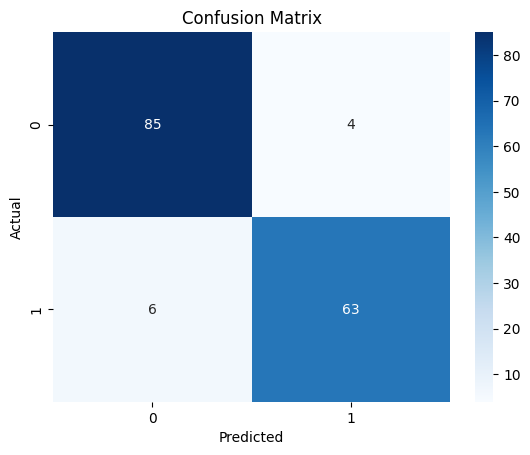

In [21]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

In [22]:
y_prob=model.predict_proba(x_test)[:,1]
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9367088607594937
Precision: 0.9402985074626866
Recall   : 0.9130434782608695
F1 Score : 0.9264705882352942
ROC-AUC  : 0.9793193290994953


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94        89
           1       0.94      0.91      0.93        69

    accuracy                           0.94       158
   macro avg       0.94      0.93      0.94       158
weighted avg       0.94      0.94      0.94       158



**Random Forest**

In [24]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(n_estimators=200,random_state=15)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0], dtype=int64)

In [25]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[85,  4],
       [ 6, 63]], dtype=int64)

Text(0.5, 1.0, 'Confusion Matrix')

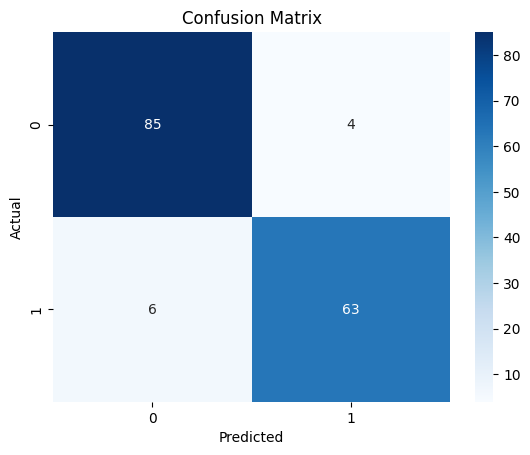

In [26]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

In [27]:
y_prob=model.predict_proba(x_test)[:,1]
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9367088607594937
Precision: 0.9402985074626866
Recall   : 0.9130434782608695
F1 Score : 0.9264705882352942
ROC-AUC  : 0.9721543722520762


In [28]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94        89
           1       0.94      0.91      0.93        69

    accuracy                           0.94       158
   macro avg       0.94      0.93      0.94       158
weighted avg       0.94      0.94      0.94       158



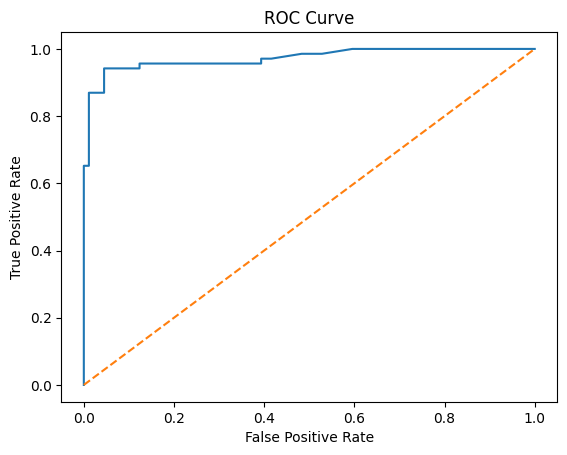

In [29]:
from sklearn.metrics import roc_curve

fpr,tpr,_ = roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [30]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    x_train,
    y_train,
    cv=5,
    scoring='f1'
)

print(scores.mean())

0.9049093621548401


In [31]:
#Saving model
import joblib
joblib.dump(model,'predictive_maintenance.pkl')

['predictive_maintenance.pkl']

In [32]:
joblib.dump(sc,'scaler.pkl')

['scaler.pkl']

In [33]:
prob = model.predict_proba(data)[0][1]
health_score = (1-prob)*100

NameError: name 'data' is not defined